In [1]:
import torch
import torch.nn as nn

from torch_geometric.nn import knn_graph
from torch_geometric.loader import DataLoader

import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import gc

In [2]:

from segnn.segnn import SEGNN
from e3nn.o3 import Irreps, spherical_harmonics
from segnn.balanced_irreps import BalancedIrreps, WeightBalancedIrreps

# use it for input features similar to hemodynamics paper
from Utility_functions import print_3D_graph, Graph_dataset_with_equiv_features

In [3]:
import os
import params

print('DATADIR', params.DATADIR)
print('NSIM', params.NSIM)
print('BATCH_SIZE', params.BATCH_SIZE)

print('torch.__version__', torch.__version__)
print('torch.cuda.is_available()', torch.cuda.is_available())

DATADIR ../.data/Dataset_1000sims_10G3N
NSIM 1000
BATCH_SIZE 1
torch.__version__ 1.10.1
torch.cuda.is_available() False


In [4]:
dev = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# dev = "cpu"
print(dev)

cpu


# Model

In [5]:
gc.collect()
torch.cuda.empty_cache()

# change the path accordingly
#path = '../Checkpoint/best_model.pt'
#path = "../.data/Dataset_1000sims_5G2N/checkpoints/best_model.pt"
#path = "../.data/Dataset_10sims_5G2N/checkpoints/best_model.pt"
#path = "../.data/Extracted_data/checkpoints/best_model.pt"
#path = "../.data/Dataset_1000sims_10G3N/checkpoints/best_model.pt"
path = os.path.join(params.DATADIR, "checkpoints/best_model.pt")
print(f"Loading model checkpoint from {str(path)}")

checkpoint = torch.load(path)

input_irreps = checkpoint['input_irreps']
hidden_irreps = checkpoint['hidden_irreps']
output_irreps = checkpoint['output_irreps']
edge_attr_irreps = checkpoint['edge_attr_irreps']
node_attr_irreps = checkpoint['node_attr_irreps']
task = checkpoint['task']
norm=checkpoint['norm']
num_layers=checkpoint['num_layers']
additional_message_irreps=checkpoint['additional_message_irreps']

model = SEGNN(input_irreps=input_irreps,
              hidden_irreps=hidden_irreps,
              output_irreps=output_irreps,
              edge_attr_irreps=edge_attr_irreps,
              node_attr_irreps=node_attr_irreps,
              task=task,
              norm=norm,
              num_layers=num_layers,
              additional_message_irreps=additional_message_irreps
              )

model = checkpoint['model']

loss_func = nn.MSELoss()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(count_parameters(model))

model.to(dev)
model.eval()

Loading model checkpoint from ../.data/Dataset_1000sims_10G3N\checkpoints/best_model.pt
1757135


SEGNN(
  (embedding_layer): O3TensorProduct(
    (tp): FullyConnectedTensorProduct(2x1o+2x0e x 1x0e+1x1o -> 130x0e+42x1o | 688 paths | 688 weights)
  )
  (layers): ModuleList(
    (0): SEGNNLayer()
    (1): SEGNNLayer()
    (2): SEGNNLayer()
    (3): SEGNNLayer()
    (4): SEGNNLayer()
    (5): SEGNNLayer()
    (6): SEGNNLayer()
    (7): SEGNNLayer()
  )
  (pre_pool1): O3TensorProductSwishGate(
    (tp): FullyConnectedTensorProduct(130x0e+42x1o x 1x0e+1x1o -> 172x0e+42x1o | 36808 paths | 36808 weights)
    (gate): Gate (172x0e+42x1o -> 130x0e+42x1o)
  )
  (pre_pool2): O3TensorProduct(
    (tp): FullyConnectedTensorProduct(130x0e+42x1o x 1x0e+1x1o -> 1x0e+1x1o | 344 paths | 344 weights)
  )
)

In [6]:
# change the root path accordingly
#dataset = Graph_dataset_with_equiv_features(root = '../data')
#dataset = Graph_dataset_with_equiv_features(root = '../.data/Dataset_1000sims_5G2N')
#dataset = Graph_dataset_with_equiv_features(root = '../.data/Dataset_10sims_5G2N')
#dataset = Graph_dataset_with_equiv_features(root = '../.data/Extracted_data')
#dataset = Graph_dataset_with_equiv_features(root = '../.data/Dataset_1000sims_10G3N')
dataset = Graph_dataset_with_equiv_features(params.DATADIR)
print(f"Loading dataset from {str(params.DATADIR)}")

100%|██████████| 1000/1000 [00:00<?, ?it/s]

Loading dataset from ../.data/Dataset_1000sims_10G3N


In [7]:
# Dataset split 80-10-10
num_workers = 8

dataset_length = len(dataset)
if True:
    train_length, test_length = train_test_split(range(dataset_length), test_size = 0.2, shuffle = False)
    val_length, test_length = train_test_split(range(len(test_length)), test_size = 0.5, shuffle = False)
else:
    train_length, test_length = list(range(1)), [0]
val_length, test_length = [0], [0]
test_dataset = dataset[test_length]

loader = DataLoader(test_dataset, batch_size = 1, shuffle = False, num_workers = num_workers)

# Test loss

In [8]:
outputs = []
loss = []

# mask = True
neighbours = 3

fluid_nodes = torch.tensor(2)

# s is the sample graph
for s in tqdm(loader): 


    edge_index = knn_graph(s.pos, neighbours, s.batch)
    s.edge_index = edge_index

    edge_relativePos = (torch.index_select(s.pos, 0, edge_index[1]) - torch.index_select(s.pos, 0, edge_index[0]))
    edge_relativeDist = torch.norm(edge_relativePos, dim = -1, keepdim = True) 
    edge_attr = torch.cat([edge_relativeDist, edge_relativePos], dim = -1) 

    s.edge_attr = edge_attr
    #s.node_attr = s.pos
    
    s = s.to(dev)
    with torch.no_grad():
        
        if s.mask is not None:
            mask = s.mask
        else:
            mask = torch.ones(s.x.shape[0], dtype=torch.bool)
            
        out = model(s)
        loss_val = loss_func(out[mask], s.y[mask])
        
    
    outputs.append(out)
    loss.append(loss_val.item())

  0%|          | 0/1 [00:00<?, ?it/s]c:\Users\crist\anaconda3\envs\segnn\lib\site-packages\torch_geometric\deprecation.py:13: UserWarning: 'contains_isolated_nodes' is deprecated, use 'has_isolated_nodes' instead
  warnings.warn(out)
100%|██████████| 1/1 [00:12<00:00, 12.00s/it]


In [9]:
# save = True
save = True

if save:
    nploss = np.save('loss.npy', loss)

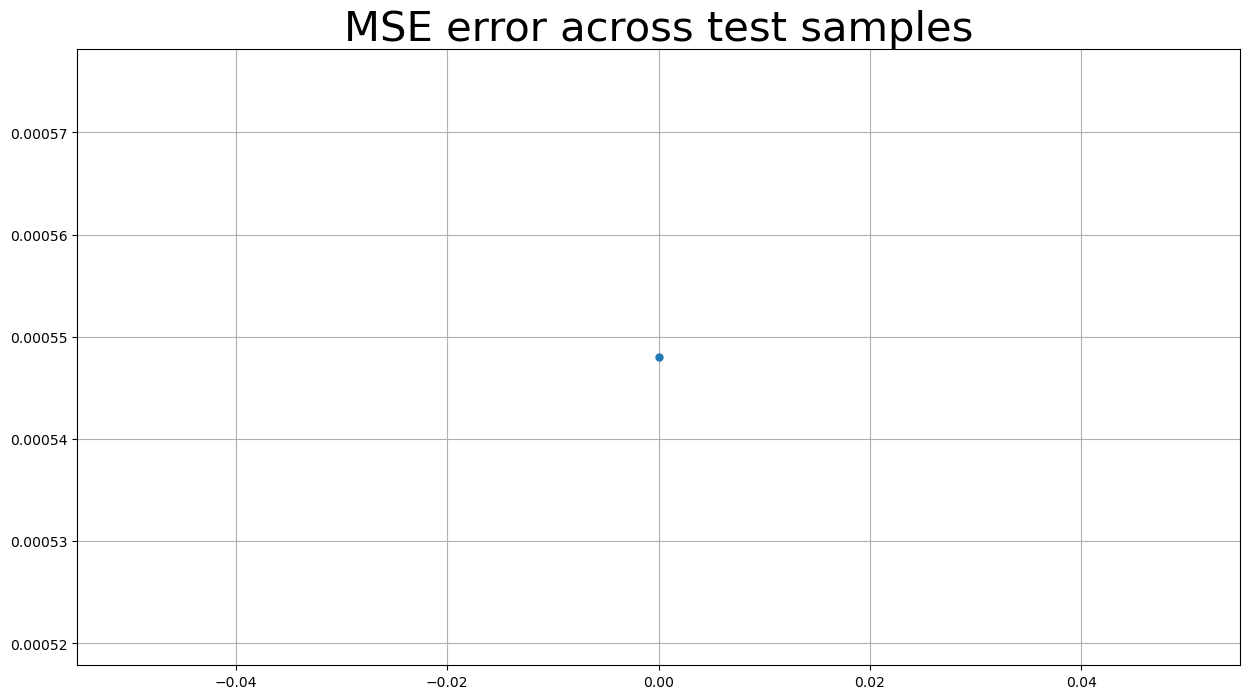

In [10]:
plt.figure(figsize=(15,8))
plt.plot(range(len(loss)), loss, marker = 'o', markersize=5,
         linewidth=0)
plt.title('MSE error across test samples', size = 30)
plt.grid()
plt.show()

# Test set plots

Number of test samples: 1


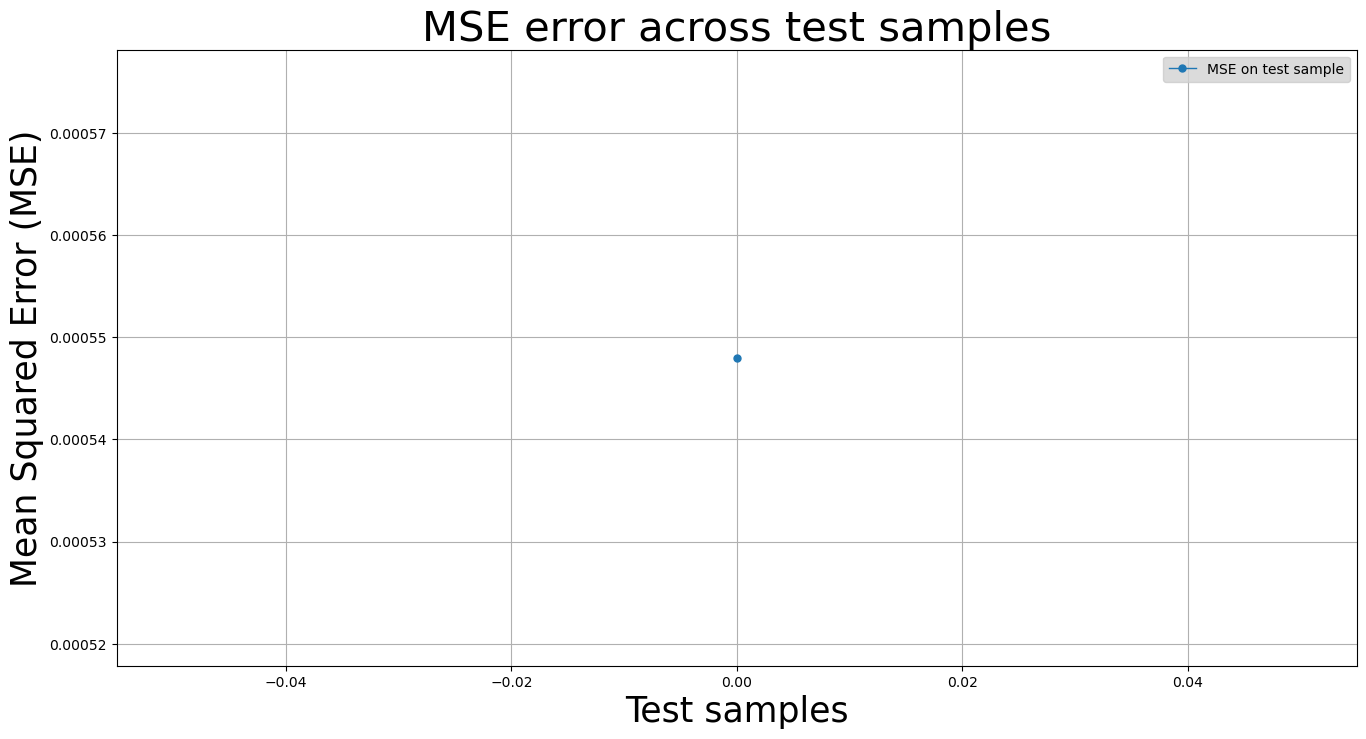

In [11]:
loadloss = np.load('loss.npy')

plt.figure(figsize=(16,8))

plt.plot(range(len(loadloss)), loadloss, marker='o', markersize=5,
         linewidth=1, label='MSE on test sample')

plt.xlabel('Test samples', size=25)
plt.ylabel('Mean Squared Error (MSE)', size=25)
plt.title('MSE error across test samples', size=30)
plt.grid()
legend = plt.legend()
legend.get_frame().set_facecolor('lightgray')

print("Number of test samples:", len(loadloss))

plt.show()

# Single test plot

In [12]:

# idx ofgraph (steady state) to plot
#idx = 4
idx = 0
test_graph = test_dataset[idx]

#test_graph = s
with torch.no_grad():

    edge_index = knn_graph(test_graph.pos, neighbours, test_graph.batch)
    test_graph.edge_index = edge_index
    
    edge_relativePos = (torch.index_select(test_graph.pos, 0, edge_index[1]) - torch.index_select(test_graph.pos, 0, edge_index[0]))
    edge_relativeDist = torch.norm(edge_relativePos, dim = -1, keepdim = True) 
    edge_attr = torch.cat([edge_relativeDist, edge_relativePos], dim = -1) 
    print(edge_attr)
    
    test_graph.edge_attr = edge_attr
    #test_graph.node_attr = test_graph.pos


    #pred = model(test_graph.to(dev))
    pred = model(test_graph.to(dev)) 
    print(test_graph)

tensor([[ 0.0500,  0.0000,  0.0000,  0.0500],
        [ 0.1000,  0.0000,  0.0000,  0.1000],
        [ 0.1186,  0.0035, -0.0105,  0.1181],
        ...,
        [ 0.0005,  0.0003, -0.0004,  0.0001],
        [ 0.0006,  0.0002, -0.0003, -0.0004],
        [ 0.0009,  0.0004, -0.0005,  0.0007]])
Data(x=[3067, 8], y=[3067, 4], pos=[3067, 3], node_attr=[3067, 4], original_pos_plus_labels=[3069, 4], mask=[3067], edge_index=[2, 9201], edge_attr=[9201, 4])


In [13]:
# remember that to plot the graphs ignoring the ground truth velocities and pressures, you have
# to plot pred[sample.mask], and not simply the "pred" tensor (which contains predictions on all nodes,
# included the ones that were masked out during training because true values were used in the input, and 
# that were not taken care of by backpropagation)

# Ground truth

In [14]:
edges = knn_graph(test_graph.pos, 3)
# print(len(test_graph.pos))
# print(test_graph.pos[1:4].tolist())
# print(test_graph.pos[0].tolist())
print(test_graph.num_features)
magvel = torch.norm(test_graph.cpu().y[...,1:4], dim=-1)
press = torch.norm(test_graph.cpu().y[...,[0]], dim=-1)

colors_magvel = magvel
colors_press = press

print_3D_graph(test_graph.pos.cpu(), edges = None, color = colors_magvel)
print_3D_graph(test_graph.pos.cpu(), edges = None, color = colors_press)

8


# Prediction

In [17]:
vicini = 3
edges = knn_graph(test_graph.pos, vicini)

magvel_pred = torch.norm(pred[mask,1:4], dim=-1)
press_pred = torch.norm(pred[mask,[0]], dim=-1)

colors_press_pred = press_pred
# colors2 = press_pred.cpu()-press
# colors2 = np.abs(press_pred.cpu()-press)/press
# colors2 = np.log10(np.abs(press2.cpu()-press)/press)

colors_magvel_pred = magvel_pred
# colors2 = np.abs(magvel2.cpu()-magvel)
# colors2 = np.abs(magvel2.cpu()-magvel)/magvel
# colors2 = np.log10(np.abs((magvel2.cpu() - magvel)/magvel))
# colors2 = press2.cpu() - press

print(pred[0].tolist())
colors_magvel = torch.norm(pred[...,1:4], dim=-1)
colors_press = torch.norm(pred[...,[0]], dim=-1) 

# colors3 = (colors3.cpu()-colors)
# colors3 = (np.abs((colors3.cpu()-colors)/colors))
# colors3 = np.log10(np.abs((colors3.cpu()-colors)/colors))

print_3D_graph(test_graph.pos.cpu(), edges = None, color = colors_magvel.cpu())
print_3D_graph(test_graph.pos.cpu(), edges = None, color = colors_press.cpu())

[-0.004284009337425232, -2.1571331672021188e-05, 6.552071863552555e-05, 0.04044482856988907]
